In [1]:
import torch

props = torch.cuda.get_device_properties(0)

print("GPU:", props.name)
print(f"Total VRAM: {props.total_memory / 1024**3:.2f} GiB")
print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GiB")
print(f"Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GiB")
print(f"Free: {torch.cuda.mem_get_info(0)[0] / 1024**3:.2f} GiB")

GPU: NVIDIA L40S
Total VRAM: 44.39 GiB
Allocated: 0.00 GiB
Reserved: 0.00 GiB
Free: 43.97 GiB


In [2]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer,  StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
tqdm.pandas(desc="Processing Rows")
import os

import gc
import time
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
import ast
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    r2_score
)
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import seaborn as sns
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
hf_token = "os.environ['HF_TOKEN']" 

/apps/common/software/Miniforge3/25.11.0-1-jupyter-base/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_id = "meta-llama/Llama-2-13b-hf"
from transformers import AutoTokenizer, AutoModelForCausalLM

hf_token = "os.environ['HF_TOKEN']" 

tokenizer = AutoTokenizer.from_pretrained(model_id,token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 363/363 [00:32<00:00, 11.06it/s]


In [4]:

df=pd.read_csv("../Datasets/World_Ecological_2015_Metadata.csv")

columns = [
    'geonameid', 'name', 'asciiname', 'alternatenames', 
    'latitude', 'longitude', 'feature_class', 'feature_code', 
    'country_code', 'cc2', 'admin1', 'admin2', 'admin3', 'admin4', 
    'population', 'elevation', 'dem', 'timezone', 'modification_date'
]

df_geo = pd.read_csv('../Datasets/allCountries.txt', sep='\t', names=columns, low_memory=False)
df_landforms = df_geo[df_geo['feature_class'] == 'T']
combined_dataset=pd.read_csv("../Datasets/Global_Named_Landforms_With_Labels.csv")
combined_dataset=combined_dataset[['name','alternatenames','feature_code','ELU_LF_Des']]
exact_6_class_map = {
    # 1: Plains
    'PLN': 1, 'PLNS': 1, 'FLT': 1, 'PANS': 1,
    
    # 2: Hills and Low Tablelands
    'HLL': 2, 'HLLS': 2, 'MND': 2, 'KNOB': 2,
    
    # 3: High Tablelands
    'PT': 3, 'PLAT': 3, 'MESA': 3, 'BUTT': 3,
    
    # 4: Ridges
    'RDG': 4, 'RDGS': 4, 'SADL': 4, 'DUNE': 4,
    
    # 5: Widely Spaced Mountains
    'MT': 5, 'MTS': 5, 'PK': 5, 'PKS': 5, 'CONE': 5, 'VOLC': 5, 'NUP': 5, 'RK': 5,
    
    # 7: Depressions or Basins
    'BSN': 7, 'BSNS': 7, 'DPR': 7, 'SINK': 7, 'CRQS': 7, 'CRATER': 7
}

combined_dataset['macro_class_id'] = combined_dataset['feature_code'].map(exact_6_class_map)
combined_dataset = combined_dataset.dropna(subset=['macro_class_id'])
combined_dataset['macro_class_id'] = combined_dataset['macro_class_id'].astype(int)
combined_dataset=combined_dataset[~combined_dataset['macro_class_id'].isna()]
combined_dataset=combined_dataset[['name','macro_class_id']]
combined_dataset.columns=['Bridges Full Name','Topographic']
combined_dataset = combined_dataset.groupby('Bridges Full Name')['Topographic'].apply(lambda x: list(set(x))).reset_index()
ascii_mask = combined_dataset['Bridges Full Name'].astype(str).str.contains(r'^[\x00-\x7F]+$')
combined_dataset = combined_dataset[ascii_mask].reset_index(drop=True)
combined_dataset

/localscratch/492863/ipykernel_719009/1853054812.py:12: DtypeWarning: Columns (9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_dataset=pd.read_csv("../Datasets/Global_Named_Landforms_With_Labels.csv")


,Bridges Full Name,Topographic
0,'Adade Yus Mountain,[5]
1,'Aqabat Nikid,[5]
2,'Elb Chouf,[4]
3,'Elb ech Chaoufa,[4]
4,'S Airde Beinn,[2]
...,...,...
618599,wzgorze na Katarynkach,[2]
618600,wzgorze nad Tuchlinkiem,[2]
618601,yak Gawa,[5]
618602,ytre Midtberget,[2]


In [5]:
combined_dataset.iloc[1000:1040]

,Bridges Full Name,Topographic
1000,Ach-Chaqra,[5]
1001,Ach-Chgigat Al Lwilbat,[2]
1002,Acha,[5]
1003,Acha Rock,[5]
1004,Achab Alhoumre,[2]
1005,Achab se Berge,[2]
1006,Achaboi,[2]
1007,Achacanani Pampa,[1]
1008,Achachked,[5]
1009,Achada Bargado,[3]


In [6]:
def label_to_list(x):
    if isinstance(x, np.ndarray):
        return [int(v) for v in x.tolist()]

    if isinstance(x, (list, tuple)):
        return [int(v) for v in x]

    if isinstance(x, str):
        x = x.strip()
        if x.startswith("["):
            return [int(v) for v in ast.literal_eval(x)]
        return [int(float(x))]

    return [int(x)]


X = combined_dataset["Bridges Full Name"].astype(str)
y_labels = combined_dataset["Topographic"].apply(label_to_list)

# optional: stratify by exact label-combination string
y_combo = y_labels.apply(lambda z: tuple(sorted(z)))

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X,
    y_labels,
    test_size=0.20,
    stratify=None,
    random_state=42
)
MAX_TRAIN = 100000
MAX_TEST = 20000

train_combo = y_train_full.apply(lambda z: tuple(sorted(z)))
test_combo = y_test_full.apply(lambda z: tuple(sorted(z)))

X_train_list, _, y_train_labels, _ = train_test_split(
    X_train_full.tolist(),
    y_train_full.tolist(),
    train_size=min(MAX_TRAIN, len(X_train_full)),
    stratify=None,
    random_state=42
)

X_test_list, _, y_test_labels, _ = train_test_split(
    X_test_full.tolist(),
    y_test_full.tolist(),
    train_size=min(MAX_TEST, len(X_test_full)),
    stratify=None,
    random_state=42
)

mlb = MultiLabelBinarizer()
Y_train = mlb.fit_transform(y_train_labels)
Y_test = mlb.transform(y_test_labels)

print("Classes:", mlb.classes_)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)


In [7]:
# import pickle

# with open("train_cache.pkl", "wb") as f:
#     pickle.dump(train_cache, f)

# with open("test_cache.pkl", "wb") as f:
#     pickle.dump(test_cache, f)
# with open("labels.pkl", "wb") as f:
#     pickle.dump({
#         "Y_train": Y_train,
#         "Y_test": Y_test
#     }, f)

In [8]:
# import pickle

# with open("train_cache.pkl", "rb") as f:
#     train_cache = pickle.load(f)

# with open("test_cache.pkl", "rb") as f:
#     test_cache = pickle.load(f)

# with open("labels.pkl", "rb") as f:
#     labels = pickle.load(f)

# Y_train = labels["Y_train"]
# Y_test = labels["Y_test"]

In [9]:
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
torch.set_num_threads(8)
torch.cuda.empty_cache()
BATCH_SIZE = 128
MAX_LEN = 64
num_blocks = len(model.model.layers)
# num_blocks = len(model.gpt_neox.layers)
print("Transformer blocks:", num_blocks)
HIDDEN_STATE_LAYERS = [36]


if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model.eval()
model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()

train_loader = DataLoader(
    X_train_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    X_test_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
# first extract layers
def extract_selected_token_states(loader, desc, hidden_state_layers):
    chunks = {l: [] for l in hidden_state_layers}

    with torch.inference_mode():
        for batch in tqdm(loader, desc=desc):
            inputs = tokenizer(
                list(batch),
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            ).to(model.device)
            lengths = inputs["attention_mask"].sum(dim=1) - 1
            batch_idx = torch.arange(inputs["input_ids"].shape[0], device=model.device)

            with torch.inference_mode():
                outputs = model(
                    **inputs,
                    output_hidden_states=True,
                    use_cache=False
                )

            for l in hidden_state_layers:
                hs = outputs.hidden_states[l]
                tok_state = hs[batch_idx, lengths, :]
                chunks[l].append(tok_state.float().cpu().numpy().astype(np.float32))

            del inputs, outputs, lengths, batch_idx, tok_state
            gc.collect()

    return {l: np.vstack(chunks[l]) for l in hidden_state_layers}

start = time.perf_counter()

print("\nExtracting train hidden states...")
train_cache = extract_selected_token_states(train_loader, "Train", HIDDEN_STATE_LAYERS)

print("\nExtracting test hidden states...")
test_cache = extract_selected_token_states(test_loader, "Test", HIDDEN_STATE_LAYERS)

print(f"\nExtraction time: {(time.perf_counter() - start) / 60:.2f} min")

np.save("train_layer36.npy", train_cache[36])
np.save("test_layer36.npy", test_cache[36])

Transformer blocks: 40

Extracting train hidden states...


Train: 100%|██████████| 782/782 [07:56<00:00,  1.64it/s]



Extracting test hidden states...


Test: 100%|██████████| 157/157 [01:34<00:00,  1.66it/s]



Extraction time: 9.55 min


In [9]:
train_cache = np.load("train_layer36.npy")
test_cache = np.load("test_layer36.npy")

In [11]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)

REP_LAYER = 36
COMPONENTS = 32
N = 5000
RANDOM_STATE = 42

Xtr = np.asarray(train_cache)
Xte = np.asarray(test_cache)

rng = np.random.default_rng(RANDOM_STATE)

train_idx = rng.choice(
    len(Xtr),
    size=min(N, len(Xtr)),
    replace=False,
)

test_idx = rng.choice(
    len(Xte),
    size=min(N, len(Xte)),
    replace=False,
)

Xtr_small = Xtr[train_idx]
Ytr_small = np.asarray(Y_train)[train_idx]

Xte_small = Xte[test_idx]
Yte_small = np.asarray(Y_test)[test_idx]

# Learn PCA only from training data.
pca = PCA(
    n_components=COMPONENTS,
    random_state=RANDOM_STATE,
)

Xtr_pca = pca.fit_transform(Xtr_small)
Xte_pca = pca.transform(Xte_small)

# Put PCA components on comparable scales.
scaler = StandardScaler()
Xtr_gp = scaler.fit_transform(Xtr_pca)
Xte_gp = scaler.transform(Xte_pca)

gps = {}
gp_results = []

for col_idx, raw_label in enumerate(mlb.classes_):
    print(f"\nTraining GP for {raw_label}")

    ytr = Ytr_small[:, col_idx].astype(float)
    yte = Yte_small[:, col_idx].astype(int)

    if np.unique(ytr).size < 2:
        print("Skipped: the training subset does not contain both classes.")
        continue

    kernel = (
        ConstantKernel(1.0, (1e-2, 1e2))
        * RBF(1.0, (1e-2, 1e2))
        + WhiteKernel(0.1, (1e-5, 1e1))
    )

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        alpha=1e-6,
        random_state=RANDOM_STATE,
    )

    gpr.fit(Xtr_gp, ytr)

    score, uncertainty = gpr.predict(
        Xte_gp,
        return_std=True,
    )

    prediction = (score >= 0.5).astype(int)
    correct = prediction == yte

    result = {
        "raw_label": raw_label,
        "column": col_idx,
        "positive_count": int(yte.sum()),
        "positive_rate": float(yte.mean()),
        "accuracy": accuracy_score(yte, prediction),
        "f1": f1_score(yte, prediction, zero_division=0),
        "precision": precision_score(
            yte, prediction, zero_division=0
        ),
        "recall": recall_score(
            yte, prediction, zero_division=0
        ),
        "score_mean": float(score.mean()),
        "uncertainty_mean": float(uncertainty.mean()),
        "uncertainty_correct": (
            float(uncertainty[correct].mean())
            if correct.any()
            else np.nan
        ),
        "uncertainty_incorrect": (
            float(uncertainty[~correct].mean())
            if (~correct).any()
            else np.nan
        ),
    }

    # These metrics require both classes in the test subset.
    if np.unique(yte).size == 2:
        result["roc_auc"] = roc_auc_score(yte, score)
        result["average_precision"] = average_precision_score(
            yte, score
        )
    else:
        result["roc_auc"] = np.nan
        result["average_precision"] = np.nan

    gps[raw_label] = gpr
    gp_results.append(result)

    print("Learned kernel:", gpr.kernel_)
    print("F1:", result["f1"])
    print("Average precision:", result["average_precision"])
    print(
        "Average uncertainty on incorrect predictions:",
        result["uncertainty_incorrect"],
    )

gp_results_df = pd.DataFrame(gp_results)

best_layer = REP_LAYER
best_pca = pca
best_scaler = scaler
best_gps = gps


Training GP for 1


/home/ravim/.local/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.02**2 * RBF(length_scale=1.91) + WhiteKernel(noise_level=1e-05)
F1: 0.5846153846153846
Average precision: 0.6835684632370765
Average uncertainty on incorrect predictions: 0.12338485603187108

Training GP for 2
Learned kernel: 0.616**2 * RBF(length_scale=4.53) + WhiteKernel(noise_level=0.66)
F1: 0.6468933776527742
Average precision: 0.7521662520291446
Average uncertainty on incorrect predictions: 0.4173412162037191

Training GP for 3
Learned kernel: 0.73**2 * RBF(length_scale=3.67) + WhiteKernel(noise_level=0.314)
F1: 0.7464503042596349
Average precision: 0.8152472154874192
Average uncertainty on incorrect predictions: 0.20795701360434993

Training GP for 4
Learned kernel: 0.92**2 * RBF(length_scale=1.25) + WhiteKernel(noise_level=0.043)
F1: 0.43243243243243246
Average precision: 0.337083387633159
Average uncertainty on incorrect predictions: 0.08232390568544849

Training GP for 5
Learned kernel: 0.621**2 * RBF(length_scale=4.46) + WhiteKernel(noise_level=0.629)
F1: 0.

/home/ravim/.local/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.05**2 * RBF(length_scale=1.61) + WhiteKernel(noise_level=1e-05)
F1: 0.24242424242424243
Average precision: 0.2652579150657346
Average uncertainty on incorrect predictions: 0.10318398737552484


In [12]:
def gp_objective(gp, z, uncertainty_weight=0.5):
    mean, std = gp.predict(z[None], return_std=True)
    return mean[0] - uncertainty_weight * std[0]


def gp_gradient(
    gp,
    z,
    delta=0.01,
    uncertainty_weight=0.5
):
    grad = np.zeros_like(z, dtype=float)

    for j in range(len(z)):
        z_plus = z.copy()
        z_minus = z.copy()

        z_plus[j] += delta
        z_minus[j] -= delta

        score_plus = gp_objective(
            gp,
            z_plus,
            uncertainty_weight
        )

        score_minus = gp_objective(
            gp,
            z_minus,
            uncertainty_weight
        )

        grad[j] = (score_plus - score_minus) / (2 * delta)

    return grad


def follow_gp_gradient(
    gp,
    z0,
    total_distance,
    step_size=0.1,
    delta=0.01,
    uncertainty_weight=0.5
):
    z = z0.copy()
    distance_moved = 0.0

    while distance_moved < total_distance:
        gradient = gp_gradient(
            gp,
            z,
            delta=delta,
            uncertainty_weight=uncertainty_weight
        )

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm < 1e-8:
            break

        direction = gradient / gradient_norm

        current_step = min(
            step_size,
            total_distance - distance_moved
        )

        z = z + current_step * direction
        distance_moved += current_step

    return z

In [ ]:
X = test_cache[best_layer]
if torch.is_tensor(X): 
    X = X.detach().cpu().numpy()

l = []
Z = best_scaler.transform(best_pca.transform(X))
df = dict()
cols = []

for label, gp in best_gps.items():
    df[f"Label {label}"] = dict()
    
    for i in [0, 10, 15, 25, 100, 150, 200]:
        z0 = Z[i]
        df[f"Label {label}"][str(i)] = dict()

        m0, s0 = gp.predict(z0[None], return_std=True)

        x0 = best_pca.inverse_transform(
            best_scaler.inverse_transform(z0[None])
        )[0]

        for alpha in [
            0.1, 0.5, 0.75, 1,
         1.5,  2,
             2.5, 3, 4
        ]:
            df[f"Label {label}"][str(i)][str(alpha)] = []

            z = follow_gp_gradient(
                gp=gp,
                z0=z0,
                total_distance=alpha,
                step_size=0.1,
                delta=0.01,
                uncertainty_weight=0.5
            )

            m, s = gp.predict(z[None], return_std=True)

            x = best_pca.inverse_transform(
                best_scaler.inverse_transform(z[None])
            )[0]

            rel = np.linalg.norm(x - x0) / (
                np.linalg.norm(x0) + 1e-8
            )

            df[f"Label {label}"][str(i)][str(alpha)].append(m[0])
            df[f"Label {label}"][str(i)][str(alpha)].append(s[0])
            df[f"Label {label}"][str(i)][str(alpha)].append(rel)
            print(f"alpha {alpha} done")
        print(i)
    print(label)

In [20]:
rows = []

for label, index_data in df.items():
    for index, alpha_data in index_data.items():
        for alpha, values in alpha_data.items():
            rows.append({
                "label": label,
                "index": int(index),
                "alpha": float(alpha),
                "mean": values[0],
                "std": values[1],
                "rel_norm": values[2],
            })

plot_df = pd.DataFrame(rows)

In [21]:
plot_df.to_csv("alpha_sweep_llama.csv",index=False)

In [20]:
plot_df=pd.read_csv("alpha_sweep_llama.csv")

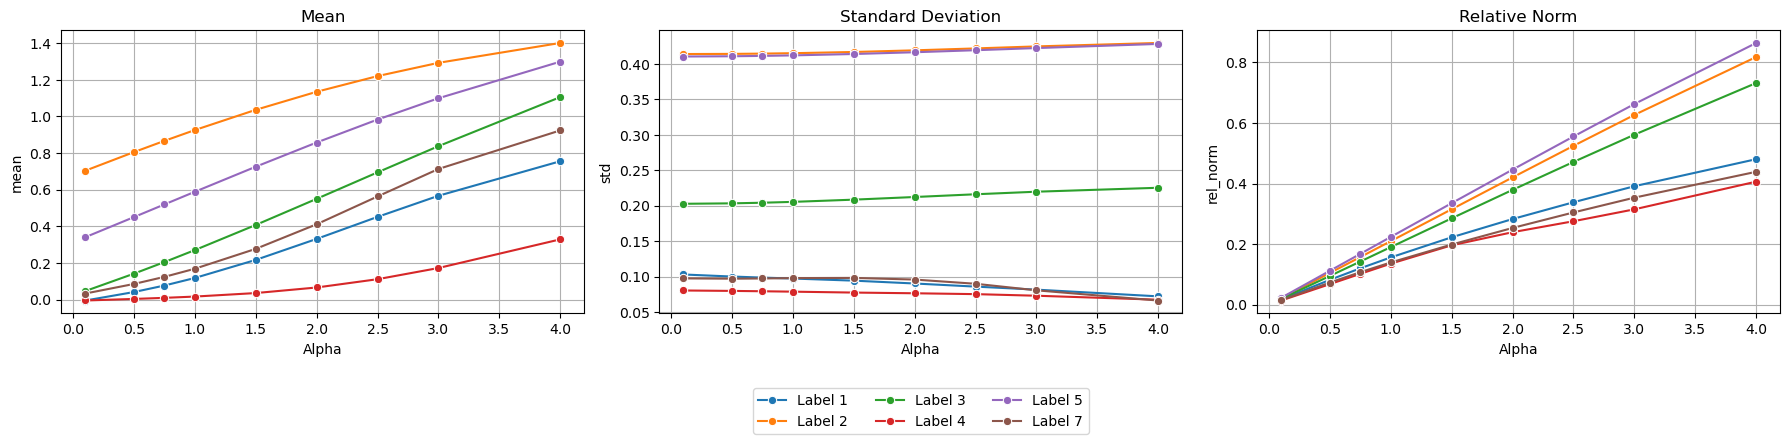

In [21]:
summary = (
    plot_df.groupby(["label", "alpha"], as_index=False)
           .agg(mean=("mean", "mean"),
                std=("std", "mean"),
                rel_norm=("rel_norm", "mean"))
)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(
    axes,
    ["mean", "std", "rel_norm"],
    ["Mean", "Standard Deviation", "Relative Norm"]
):
    sns.lineplot(
        data=summary,
        x="alpha",
        y=metric,
        hue="label",
        marker="o",
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Alpha")
    ax.grid(True)

axes[0].legend_.remove()
axes[2].legend_.remove()
axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, -0.45), ncols=3)
# plt

plt.tight_layout()
plt.show()

In [22]:
BETA = 0.5

summary["utility"] = (
    summary["mean"] - BETA * summary["std"]
)

alpha_scores = (
    summary.groupby("alpha", as_index=False)
    .agg(utility=("utility", "mean"))
)

best_alpha = float(
    alpha_scores.loc[
        alpha_scores["utility"].idxmax(),
        "alpha"
    ]
)

print("Frozen alpha:", best_alpha)

Frozen alpha: 4.0


In [11]:
def gp_gradient(
    gp,
    z,
    delta=0.01,
    uncertainty_weight=0.5,
):
    n_dims = len(z)

    offsets = np.eye(n_dims) * delta

    Z_plus = z[None, :] + offsets
    Z_minus = z[None, :] - offsets

    mean_plus, std_plus = gp.predict(
        Z_plus,
        return_std=True,
    )

    mean_minus, std_minus = gp.predict(
        Z_minus,
        return_std=True,
    )

    score_plus = (
        mean_plus - uncertainty_weight * std_plus
    )

    score_minus = (
        mean_minus - uncertainty_weight * std_minus
    )

    return (score_plus - score_minus) / (2 * delta)


def follow_gp_gradient(
    gp,
    z0,
    total_distance,
    step_size=0.5,
    delta=0.01,
    uncertainty_weight=0.5,
):
    z = np.asarray(z0, dtype=float).copy()

    n_steps = int(np.ceil(total_distance / step_size))

    for step in range(n_steps):
        gradient = gp_gradient(
            gp=gp,
            z=z,
            delta=delta,
            uncertainty_weight=uncertainty_weight,
        )

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm < 1e-8:
            break

        remaining_distance = (
            total_distance - step * step_size
        )

        current_step = min(
            step_size,
            remaining_distance,
        )

        z += current_step * (
            gradient / gradient_norm
        )

    return z

In [47]:
results_df.to_csv("res.csv",index=False)

In [62]:
results_df=pd.read_csv("res.csv")
results_df

,label,n_samples,mean_probability_before,mean_probability_after,mean_change,fraction_increased
0,1,1000,0.006000,0.063518,0.057518,0.153
1,2,1000,0.282385,0.942306,0.659921,0.995
2,3,1000,0.021419,0.816058,0.794639,0.825
3,4,1000,0.004000,0.054053,0.050053,0.152
4,5,1000,0.293653,0.927752,0.634099,0.997
5,7,1000,0.002000,0.014000,0.012000,0.123


In [13]:
for label, gp in best_gps.items():
    print(label, gp.kernel_)

1 1.02**2 * RBF(length_scale=1.91) + WhiteKernel(noise_level=1e-05)
2 0.616**2 * RBF(length_scale=4.53) + WhiteKernel(noise_level=0.66)
3 0.73**2 * RBF(length_scale=3.67) + WhiteKernel(noise_level=0.314)
4 0.92**2 * RBF(length_scale=1.25) + WhiteKernel(noise_level=0.043)
5 0.621**2 * RBF(length_scale=4.46) + WhiteKernel(noise_level=0.629)
7 1.05**2 * RBF(length_scale=1.61) + WhiteKernel(noise_level=1e-05)


In [23]:
import joblib
import numpy as np
import pandas as pd

probe = joblib.load(
    "../Probes/llama13b-probes/best_linear_probe.pkl"
)

N_EVAL = 1000

class_to_col = {
    label: i for i, label in enumerate(mlb.classes_)
}

# Put all training activations into the same space used by the GP.
Z_train = best_scaler.transform(
    best_pca.transform(Xtr_small)
)

results_fixed = []

for target_label in best_gps.keys():
    print(f"Starting: {target_label}")

    col = class_to_col[target_label]

    # Create the fixed mean-difference direction.
    positive_mask = Ytr_small[:, col] == 1
    negative_mask = Ytr_small[:, col] == 0

    positive_mean = Z_train[positive_mask].mean(axis=0)
    negative_mean = Z_train[negative_mask].mean(axis=0)

    fixed_direction = positive_mean - negative_mean

    direction_norm = np.linalg.norm(fixed_direction)

    if direction_norm < 1e-8:
        print(f"Skipping {target_label}: zero direction")
        continue

    fixed_direction = fixed_direction / direction_norm

    # Use the same evaluation samples as the GP experiment.
    eval_mask = Yte_small[:, col] == 0
    X_eval = Xte_small[eval_mask][:N_EVAL]

    if len(X_eval) == 0:
        continue

    before = probe.predict_proba(X_eval)[:, col]

    Z_eval = best_scaler.transform(
        best_pca.transform(X_eval)
    )

    # Apply the same total steering distance as the GP method.
    Z_steered = Z_eval + best_alpha * fixed_direction

    X_steered = best_pca.inverse_transform(
        best_scaler.inverse_transform(Z_steered)
    )

    after = probe.predict_proba(X_steered)[:, col]
    change = after - before

    results_fixed.append({
        "label": target_label,
        "method": "fixed_mean_difference",
        "n_samples": len(X_eval),
        "mean_probability_before": before.mean(),
        "mean_probability_after": after.mean(),
        "mean_change": change.mean(),
        "fraction_increased": (change > 0).mean(),
    })

    print(f"Finished: {target_label}")

fixed_results_df = pd.DataFrame(results_fixed)

print(fixed_results_df)

Starting: 1
Finished: 1
Starting: 2
Finished: 2
Starting: 3
Finished: 3
Starting: 4
Finished: 4
Starting: 5
Finished: 5
Starting: 7
Finished: 7
   label                 method  n_samples  mean_probability_before  \
0      1  fixed_mean_difference       1000                 0.014000   
1      2  fixed_mean_difference       1000                 0.382004   
2      3  fixed_mean_difference       1000                 0.053990   
3      4  fixed_mean_difference       1000                 0.014004   
4      5  fixed_mean_difference       1000                 0.381695   
5      7  fixed_mean_difference       1000                 0.012998   

   mean_probability_after  mean_change  fraction_increased  
0                0.705000     0.691000               0.740  
1                0.999999     0.617995               1.000  
2                0.842000     0.788010               0.825  
3                0.775994     0.761990               0.808  
4                0.992112     0.610417               

In [25]:
# Names expected by the analysis code
X_train_act = Xtr_small
X_test_act = Xte_small

Y_train_arr = Ytr_small
Y_test_arr = Yte_small

# Training activations in the GP coordinate space
Z_train = Xtr_gp

# Exact label-column order used to train the GPs and probes
class_to_col = {
    label: col
    for col, label in enumerate(mlb.classes_)
}

print("X_train_act:", X_train_act.shape)
print("X_test_act:", X_test_act.shape)
print("Y_train_arr:", Y_train_arr.shape)
print("Y_test_arr:", Y_test_arr.shape)
print("Z_train:", Z_train.shape)
print("class_to_col:", class_to_col)

X_train_act: (5000, 5120)
X_test_act: (5000, 5120)
Y_train_arr: (5000, 6)
Y_test_arr: (5000, 6)
Z_train: (5000, 32)
class_to_col: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(7): 5}


Label: 1
start
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
Label: 2
start
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
Label: 3
start
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
heree
here
here

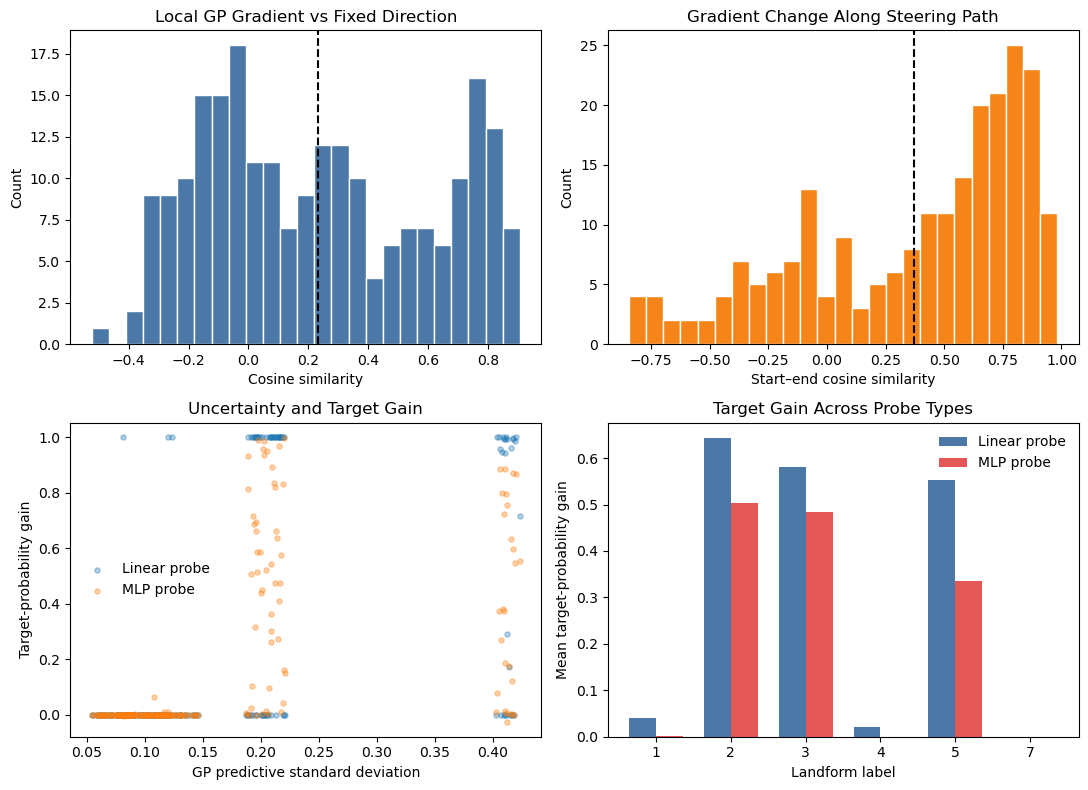

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
ALPHA=3.0
N_EVAL=50
# Change only this path if your MLP filename differs
linear_probe = joblib.load(
    "../Probes/llama13b-probes/best_linear_probe.pkl"
)
nonlinear_probe = joblib.load(
    "../Probes/llama13b-probes/best_nonlinear_probe.pkl"
)

def get_probs(model, X):
    p = model.predict_proba(X)

    # Handles sklearn MultiOutputClassifier
    if isinstance(p, list):
        return np.column_stack([
            x[:, 1] if x.shape[1] > 1 else x[:, 0]
            for x in p
        ])

    p = np.asarray(p)

    if p.ndim == 3:
        return p[:, :, 1]

    return p


rows = []

for label, gp in best_gps.items():
    print("Label:", label)
    c = class_to_col[label]

    # Global fixed-vector reference
    fixed = (
        Z_train[Y_train_arr[:, c] == 1].mean(axis=0)
        - Z_train[Y_train_arr[:, c] == 0].mean(axis=0)
    )
    fixed /= np.linalg.norm(fixed) + 1e-12

    # Target absent and at least two existing labels
    idx = np.where(
        (Y_test_arr[:, c] == 0) &
        (Y_test_arr.sum(axis=1) >= 2)
    )[0][:N_EVAL]
    print("start")
    for i in idx:
        x0 = X_test_act[i]

        z0 = best_scaler.transform(
            best_pca.transform(x0[None])
        )[0]

        # Initial uncertainty-aware GP gradient
        g0 = gp_gradient(
            gp=gp,
            z=z0,
            delta=0.01,
            uncertainty_weight=BETA
        )
        g0 /= np.linalg.norm(g0) + 1e-12
        print("here")
        # Iterative gradient-ascent steering
        z1 = follow_gp_gradient(
            gp=gp,
            z0=z0,
            total_distance=ALPHA,
            step_size=0.1,
            delta=0.01,
            uncertainty_weight=BETA
        )
        print("heree")
        # Gradient at end of path
        g1 = gp_gradient(
            gp=gp,
            z=z1,
            delta=0.01,
            uncertainty_weight=BETA
        )
        g1 /= np.linalg.norm(g1) + 1e-12

        # GP uncertainty before steering
        _, std0 = gp.predict(
            z0[None],
            return_std=True
        )

        # Return steered point to original activation space
        x1 = best_pca.inverse_transform(
            best_scaler.inverse_transform(z1[None])
        )

        # Linear-probe evaluation
        lin_before = get_probs(linear_probe, x0[None])[0]
        lin_after = get_probs(linear_probe, x1)[0]

        # Nonlinear-probe evaluation
        mlp_before = get_probs(nonlinear_probe, x0[None])[0]
        mlp_after = get_probs(nonlinear_probe, x1)[0]

        existing = Y_test_arr[i].astype(bool)

        rows.append({
            "label": label,
            "sample": int(i),

            # Geometry
            "gp_to_fixed": float(g0 @ fixed),
            "start_to_end": float(g0 @ g1),
            "uncertainty": float(std0[0]),
            "direction": g0,

            # Linear probe
            "linear_target_gain": float(
                lin_after[c] - lin_before[c]
            ),
            "linear_damage": float(
                np.maximum(
                    lin_before[existing]
                    - lin_after[existing],
                    0
                ).mean()
            ),
            "linear_increased": float(
                lin_after[c] > lin_before[c]
            ),

            # Nonlinear probe
            "mlp_target_gain": float(
                mlp_after[c] - mlp_before[c]
            ),
            "mlp_damage": float(
                np.maximum(
                    mlp_before[existing]
                    - mlp_after[existing],
                    0
                ).mean()
            ),
            "mlp_increased": float(
                mlp_after[c] > mlp_before[c]
            )
        })


results_df = pd.DataFrame(rows)

# ---------- Per-landform table ----------

summary = []

for label, group in results_df.groupby("label"):
    
    D = np.stack(group["direction"])
    n = len(D)

    # Mean pairwise GP-gradient cosine
    if n > 1:
        gp_to_gp = (
            np.linalg.norm(D.sum(axis=0)) ** 2 - n
        ) / (n * (n - 1))
    else:
        gp_to_gp = np.nan

    summary.append({
        "label": label,
        "n": n,

        "GP–GP cosine":
            gp_to_gp,

        "GP–fixed cosine":
            group["gp_to_fixed"].mean(),

        "start–end cosine":
            group["start_to_end"].mean(),

        "uncertainty–linear gain ρ":
            group["uncertainty"].corr(
                group["linear_target_gain"],
                method="spearman"
            ),

        "uncertainty–MLP gain ρ":
            group["uncertainty"].corr(
                group["mlp_target_gain"],
                method="spearman"
            ),

        "uncertainty–linear damage ρ":
            group["uncertainty"].corr(
                group["linear_damage"],
                method="spearman"
            ),

        "uncertainty–MLP damage ρ":
            group["uncertainty"].corr(
                group["mlp_damage"],
                method="spearman"
            ),

        "linear target gain":
            group["linear_target_gain"].mean(),

        "MLP target gain":
            group["mlp_target_gain"].mean(),

        "linear fraction increased":
            group["linear_increased"].mean(),

        "MLP fraction increased":
            group["mlp_increased"].mean()
    })

summary_df = pd.DataFrame(summary)

print("\nPER-LANDFORM RESULTS")
print(summary_df.round(3).to_string(index=False))


# ---------- Overall table ----------

all_D = np.stack(results_df["direction"])
n = len(all_D)

overall_gp_to_gp = (
    np.linalg.norm(all_D.sum(axis=0)) ** 2 - n
) / (n * (n - 1))

overall_df = pd.DataFrame({
    "metric": [
        "GP–GP cosine",
        "GP–fixed cosine",
        "start–end cosine",
        "uncertainty–linear gain Spearman ρ",
        "uncertainty–MLP gain Spearman ρ",
        "uncertainty–linear damage Spearman ρ",
        "uncertainty–MLP damage Spearman ρ",
        "mean linear target gain",
        "mean MLP target gain",
        "linear fraction increased",
        "MLP fraction increased"
    ],
    "value": [
        overall_gp_to_gp,
        results_df["gp_to_fixed"].mean(),
        results_df["start_to_end"].mean(),

        results_df["uncertainty"].corr(
            results_df["linear_target_gain"],
            method="spearman"
        ),

        results_df["uncertainty"].corr(
            results_df["mlp_target_gain"],
            method="spearman"
        ),

        results_df["uncertainty"].corr(
            results_df["linear_damage"],
            method="spearman"
        ),

        results_df["uncertainty"].corr(
            results_df["mlp_damage"],
            method="spearman"
        ),

        results_df["linear_target_gain"].mean(),
        results_df["mlp_target_gain"].mean(),
        results_df["linear_increased"].mean(),
        results_df["mlp_increased"].mean()
    ]
})

print("\nOVERALL RESULTS")
print(overall_df.round(3).to_string(index=False))


# ---------- Publication figure ----------

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# A: GP versus fixed
axes[0, 0].hist(
    results_df["gp_to_fixed"],
    bins=25,
    color="#4C78A8",
    edgecolor="white"
)
axes[0, 0].axvline(
    results_df["gp_to_fixed"].mean(),
    color="black",
    linestyle="--"
)
axes[0, 0].set_title("Local GP Gradient vs Fixed Direction")
axes[0, 0].set_xlabel("Cosine similarity")
axes[0, 0].set_ylabel("Count")

# B: path curvature
axes[0, 1].hist(
    results_df["start_to_end"],
    bins=25,
    color="#F58518",
    edgecolor="white"
)
axes[0, 1].axvline(
    results_df["start_to_end"].mean(),
    color="black",
    linestyle="--"
)
axes[0, 1].set_title("Gradient Change Along Steering Path")
axes[0, 1].set_xlabel("Start–end cosine similarity")
axes[0, 1].set_ylabel("Count")

# C: uncertainty versus gain
axes[1, 0].scatter(
    results_df["uncertainty"],
    results_df["linear_target_gain"],
    alpha=0.35,
    s=14,
    label="Linear probe"
)
axes[1, 0].scatter(
    results_df["uncertainty"],
    results_df["mlp_target_gain"],
    alpha=0.35,
    s=14,
    label="MLP probe"
)
axes[1, 0].set_title("Uncertainty and Target Gain")
axes[1, 0].set_xlabel("GP predictive standard deviation")
axes[1, 0].set_ylabel("Target-probability gain")
axes[1, 0].legend(frameon=False)

# D: per-landform probe agreement
x = np.arange(len(summary_df))
width = 0.36

axes[1, 1].bar(
    x - width / 2,
    summary_df["linear target gain"],
    width,
    label="Linear probe",
    color="#4C78A8"
)
axes[1, 1].bar(
    x + width / 2,
    summary_df["MLP target gain"],
    width,
    label="MLP probe",
    color="#E45756"
)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(summary_df["label"])
axes[1, 1].set_title("Target Gain Across Probe Types")
axes[1, 1].set_xlabel("Landform label")
axes[1, 1].set_ylabel("Mean target-probability gain")
axes[1, 1].legend(frameon=False)

plt.tight_layout()
# plt.savefig(
#     "gp_landform_interpretability.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()

# results_df.drop(columns="direction").to_csv(
#     "gp_sample_results.csv",
#     index=False
# )
# summary_df.to_csv(
#     "gp_landform_summary.csv",
#     index=False
# )
# overall_df.to_csv(
#     "gp_overall_summary.csv",
#     index=False
# )

In [29]:
N_EVAL

1000

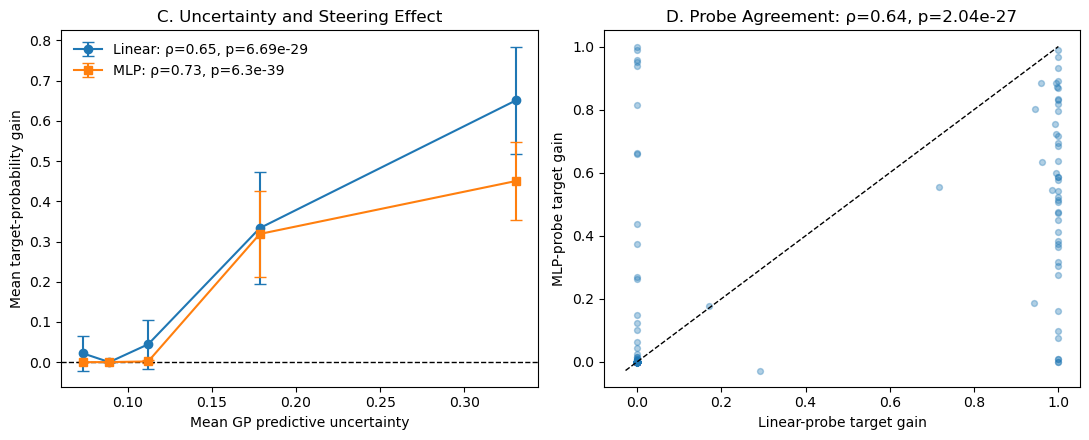

 label  n  uncertainty–linear gain ρ  uncertainty–linear gain p  uncertainty–MLP gain ρ  uncertainty–MLP gain p  linear–MLP agreement ρ  linear–MLP agreement p  same gain direction
     1 50                      0.201                      0.161                   0.177                   0.219                   0.428                   0.002                0.120
     2 11                      0.545                      0.083                   0.364                   0.272                   0.836                   0.001                1.000
     3 50                      0.234                      0.101                   0.095                   0.513                   0.260                   0.068                0.660
     4 50                      0.215                      0.134                   0.249                   0.081                   0.258                   0.071                0.080
     5 16                     -0.503                      0.047                  -0.265        

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# =========================================================
# C. UNCERTAINTY VS STEERING EFFECT
# Use uncertainty quantile bins instead of a striped scatter
# =========================================================

plot_df = results_df.copy()

plot_df["uncertainty_bin"] = pd.qcut(
    plot_df["uncertainty"],
    q=5,
    duplicates="drop"
)

uncertainty_summary = (
    plot_df.groupby("uncertainty_bin", observed=True)
    .agg(
        uncertainty=("uncertainty", "mean"),
        linear_gain=("linear_target_gain", "mean"),
        linear_sem=("linear_target_gain", "sem"),
        mlp_gain=("mlp_target_gain", "mean"),
        mlp_sem=("mlp_target_gain", "sem"),
        n=("sample", "count")
    )
    .reset_index()
)

rho_lin, p_lin = spearmanr(
    results_df["uncertainty"],
    results_df["linear_target_gain"],
    nan_policy="omit"
)

rho_mlp, p_mlp = spearmanr(
    results_df["uncertainty"],
    results_df["mlp_target_gain"],
    nan_policy="omit"
)

axes[0].errorbar(
    uncertainty_summary["uncertainty"],
    uncertainty_summary["linear_gain"],
    yerr=1.96 * uncertainty_summary["linear_sem"],
    marker="o",
    capsize=4,
    label=f"Linear: ρ={rho_lin:.2f}, p={p_lin:.3g}"
)

axes[0].errorbar(
    uncertainty_summary["uncertainty"],
    uncertainty_summary["mlp_gain"],
    yerr=1.96 * uncertainty_summary["mlp_sem"],
    marker="s",
    capsize=4,
    label=f"MLP: ρ={rho_mlp:.2f}, p={p_mlp:.3g}"
)

axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("Mean GP predictive uncertainty")
axes[0].set_ylabel("Mean target-probability gain")
axes[0].set_title("C. Uncertainty and Steering Effect")
axes[0].legend(frameon=False)


# =========================================================
# D. LINEAR VS MLP PROBE AGREEMENT
# Per-sample agreement, not only per-label means
# =========================================================

rho_probe, p_probe = spearmanr(
    results_df["linear_target_gain"],
    results_df["mlp_target_gain"],
    nan_policy="omit"
)

axes[1].scatter(
    results_df["linear_target_gain"],
    results_df["mlp_target_gain"],
    alpha=0.35,
    s=18
)

low = min(
    results_df["linear_target_gain"].min(),
    results_df["mlp_target_gain"].min()
)

high = max(
    results_df["linear_target_gain"].max(),
    results_df["mlp_target_gain"].max()
)

axes[1].plot(
    [low, high],
    [low, high],
    color="black",
    linestyle="--",
    linewidth=1
)

axes[1].set_xlabel("Linear-probe target gain")
axes[1].set_ylabel("MLP-probe target gain")
axes[1].set_title(
    f"D. Probe Agreement: ρ={rho_probe:.2f}, p={p_probe:.3g}"
)

plt.tight_layout()
plt.savefig(
    "uncertainty_and_probe_agreement.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# =========================================================
# PUBLISHABLE NUMERICAL TABLE
# =========================================================

table_rows = []

for label, group in results_df.groupby("label"):
    uncertainty_linear = spearmanr(
        group["uncertainty"],
        group["linear_target_gain"],
        nan_policy="omit"
    )

    uncertainty_mlp = spearmanr(
        group["uncertainty"],
        group["mlp_target_gain"],
        nan_policy="omit"
    )

    probe_agreement = spearmanr(
        group["linear_target_gain"],
        group["mlp_target_gain"],
        nan_policy="omit"
    )

    same_direction = np.mean(
        np.sign(group["linear_target_gain"])
        == np.sign(group["mlp_target_gain"])
    )

    table_rows.append({
        "label": label,
        "n": len(group),
        "uncertainty–linear gain ρ": uncertainty_linear.statistic,
        "uncertainty–linear gain p": uncertainty_linear.pvalue,
        "uncertainty–MLP gain ρ": uncertainty_mlp.statistic,
        "uncertainty–MLP gain p": uncertainty_mlp.pvalue,
        "linear–MLP agreement ρ": probe_agreement.statistic,
        "linear–MLP agreement p": probe_agreement.pvalue,
        "same gain direction": same_direction
    })

panel_cd_table = pd.DataFrame(table_rows)

print(panel_cd_table.round(3).to_string(index=False))

panel_cd_table.to_csv(
    "panel_C_D_results.csv",
    index=False
)

Label: 1
Label: 2
Label: 3
Label: 4
Label: 5
Label: 7

OVERALL BETA ABLATION
               metric  beta_0_mean  beta_aware_mean  paired_difference
mean_path_uncertainty       0.1666           0.1476            -0.0190
    final_uncertainty       0.1711           0.1411            -0.0300
   linear_target_gain       0.2198           0.2112            -0.0086
      mlp_target_gain       0.1543           0.1548             0.0005
        linear_damage       0.2069           0.2059            -0.0010
           mlp_damage       0.1844           0.1747            -0.0097

PER-LANDFORM BETA ABLATION
 label  Δ path uncertainty  Δ final uncertainty  Δ linear gain  Δ MLP gain  Δ linear damage  Δ MLP damage
     1             -0.0357              -0.0561        -0.0200     -0.0000          -0.0134       -0.0147
     2             -0.0003              -0.0007         0.0040      0.0039           0.0000        0.0008
     3             -0.0010              -0.0017         0.0000      0.0013      

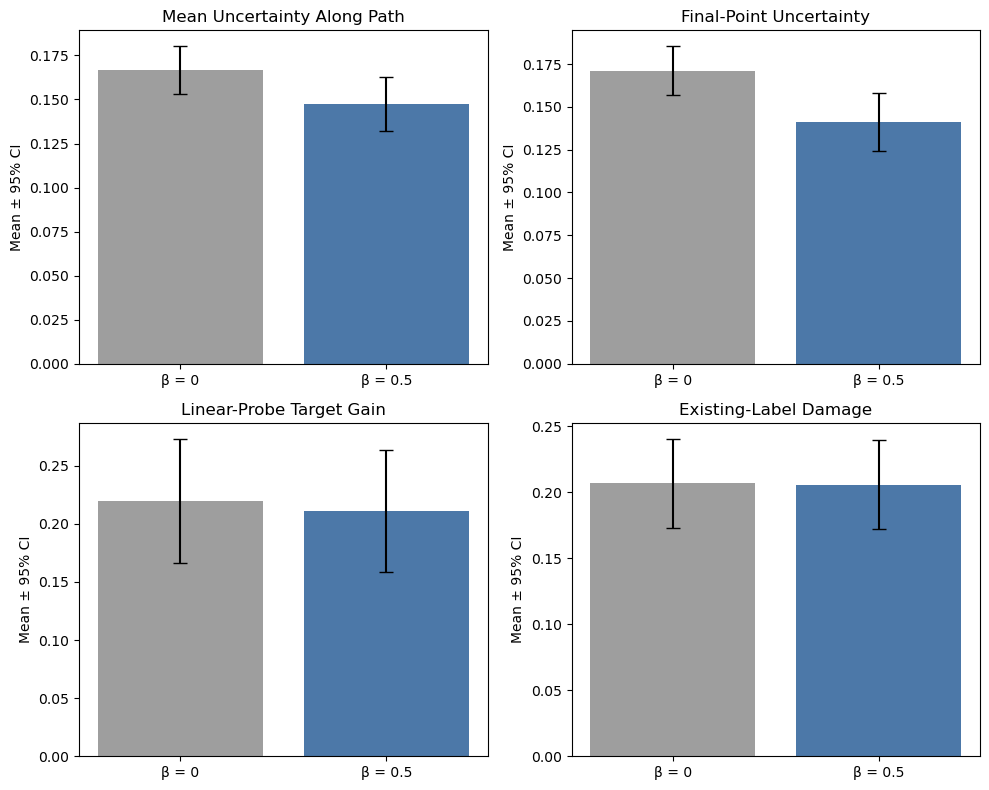

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STEP_SIZE = 0.1
DELTA = 0.01
BETA_VALUES = [0.0, BETA]


def follow_gp_gradient_with_path(
    gp,
    z0,
    total_distance,
    step_size,
    delta,
    uncertainty_weight
):
    z = z0.copy()
    path = [z.copy()]
    travelled = 0.0

    while travelled < total_distance:
        g = gp_gradient(
            gp=gp,
            z=z,
            delta=delta,
            uncertainty_weight=uncertainty_weight
        )

        norm = np.linalg.norm(g)
        if norm < 1e-12:
            break

        g = g / norm
        step = min(step_size, total_distance - travelled)

        z = z + step * g
        path.append(z.copy())
        travelled += step

    return z, np.asarray(path)


rows = []

for label, gp in best_gps.items():
    print("Label:", label)
    c = class_to_col[label]

    idx = np.where(
        (Y_test_arr[:, c] == 0) &
        (Y_test_arr.sum(axis=1) >= 2)
    )[0][:N_EVAL]

    for i in idx:
        x0 = X_test_act[i]

        z0 = best_scaler.transform(
            best_pca.transform(x0[None])
        )[0]

        lin_before = get_probs(
            linear_probe, x0[None]
        )[0]

        mlp_before = get_probs(
            nonlinear_probe, x0[None]
        )[0]

        existing = Y_test_arr[i].astype(bool)

        for beta in BETA_VALUES:
            z1, path = follow_gp_gradient_with_path(
                gp=gp,
                z0=z0,
                total_distance=ALPHA,
                step_size=STEP_SIZE,
                delta=DELTA,
                uncertainty_weight=beta
            )

            # Uncertainty over the complete steering path
            _, path_std = gp.predict(
                path,
                return_std=True
            )

            x1 = best_pca.inverse_transform(
                best_scaler.inverse_transform(z1[None])
            )

            lin_after = get_probs(
                linear_probe, x1
            )[0]

            mlp_after = get_probs(
                nonlinear_probe, x1
            )[0]

            rows.append({
                "label": label,
                "sample": int(i),
                "beta": beta,

                "mean_path_uncertainty":
                    float(path_std.mean()),

                "final_uncertainty":
                    float(path_std[-1]),

                "linear_target_gain":
                    float(lin_after[c] - lin_before[c]),

                "mlp_target_gain":
                    float(mlp_after[c] - mlp_before[c]),

                "linear_damage":
                    float(np.maximum(
                        lin_before[existing]
                        - lin_after[existing],
                        0
                    ).mean()),

                "mlp_damage":
                    float(np.maximum(
                        mlp_before[existing]
                        - mlp_after[existing],
                        0
                    ).mean())
            })


beta_df = pd.DataFrame(rows)

# --------------------------------------------------
# Paired differences: uncertainty-aware minus beta=0
# --------------------------------------------------

metrics = [
    "mean_path_uncertainty",
    "final_uncertainty",
    "linear_target_gain",
    "mlp_target_gain",
    "linear_damage",
    "mlp_damage"
]

paired = beta_df.pivot(
    index=["label", "sample"],
    columns="beta",
    values=metrics
)

beta_aware = BETA

difference_rows = []

for metric in metrics:
    difference_rows.append({
        "metric": metric,
        "beta_0_mean": paired[metric][0.0].mean(),
        "beta_aware_mean": paired[metric][beta_aware].mean(),
        "paired_difference": (
            paired[metric][beta_aware]
            - paired[metric][0.0]
        ).mean()
    })

beta_summary = pd.DataFrame(difference_rows)

print("\nOVERALL BETA ABLATION")
print(beta_summary.round(4).to_string(index=False))


# --------------------------------------------------
# Per-landform table
# --------------------------------------------------

landform_rows = []

for label, group in beta_df.groupby("label"):
    p = group.pivot(
        index="sample",
        columns="beta",
        values=metrics
    )

    landform_rows.append({
        "label": label,

        "Δ path uncertainty":
            (p["mean_path_uncertainty"][beta_aware]
             - p["mean_path_uncertainty"][0.0]).mean(),

        "Δ final uncertainty":
            (p["final_uncertainty"][beta_aware]
             - p["final_uncertainty"][0.0]).mean(),

        "Δ linear gain":
            (p["linear_target_gain"][beta_aware]
             - p["linear_target_gain"][0.0]).mean(),

        "Δ MLP gain":
            (p["mlp_target_gain"][beta_aware]
             - p["mlp_target_gain"][0.0]).mean(),

        "Δ linear damage":
            (p["linear_damage"][beta_aware]
             - p["linear_damage"][0.0]).mean(),

        "Δ MLP damage":
            (p["mlp_damage"][beta_aware]
             - p["mlp_damage"][0.0]).mean()
    })

beta_landform_table = pd.DataFrame(landform_rows)

print("\nPER-LANDFORM BETA ABLATION")
print(beta_landform_table.round(4).to_string(index=False))


# --------------------------------------------------
# Publication figure
# Negative uncertainty difference means beta>0
# followed a more certain path.
# --------------------------------------------------

plot_metrics = [
    "mean_path_uncertainty",
    "final_uncertainty",
    "linear_target_gain",
    "linear_damage"
]

titles = [
    "Mean Uncertainty Along Path",
    "Final-Point Uncertainty",
    "Linear-Probe Target Gain",
    "Existing-Label Damage"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, metric, title in zip(
    axes.flat, plot_metrics, titles
):
    values_0 = paired[metric][0.0]
    values_b = paired[metric][beta_aware]

    means = [values_0.mean(), values_b.mean()]
    sems = [
        values_0.sem(),
        values_b.sem()
    ]

    ax.bar(
        ["β = 0", f"β = {beta_aware}"],
        means,
        yerr=1.96 * np.asarray(sems),
        capsize=5,
        color=["#9E9E9E", "#4C78A8"]
    )

    ax.set_title(title)
    ax.set_ylabel("Mean ± 95% CI")

plt.tight_layout()
plt.savefig(
    "beta_ablation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

beta_df.to_csv(
    "beta_ablation_samples.csv",
    index=False
)

beta_summary.to_csv(
    "beta_ablation_overall.csv",
    index=False
)

beta_landform_table.to_csv(
    "beta_ablation_landforms.csv",
    index=False
)

In [36]:
print("hi")

hi
